In [1]:
from utils import load_pickle

In [2]:
nn = load_pickle('pickles/nn_results_all_24880.pkl')
eqs = load_pickle('pickles/pysr_results_all_24880_11003.pkl')
pure_sr = load_pickle('pickles/pure_sr_results_all_72420.pkl')
pure_sr2 = load_pickle('pickles/pysr_results_all_28114_41564.pkl')
petit = load_pickle('pickles/petit_results_all.pkl')

mse_nn = load_pickle('pickles/nn_results_all_12318.pkl')
mse_eqs = load_pickle('pickles/pysr_results_all_12318_93102.pkl')
pure_sr_mse = load_pickle('pickles/pure_sr_results_all_83941.pkl')
pure_sr2_mse = load_pickle('pickles/pysr_results_all_28114_93890.pkl')

In [5]:
import pandas as pd

models = {
    'nn':           nn,
    'eqs':          eqs,
    'pure_sr':      pure_sr,
    'pure_sr2':     pure_sr2,
    'petit':        petit,
    'mse_nn':       mse_nn,
    'mse_eqs':      mse_eqs,
    'pure_sr_mse':  pure_sr_mse,
    'pure_sr2_mse': pure_sr2_mse,
}

metrics = ['rmse', 'acc', 'auc', 'bias']
splits = ['test', 'random']

rows = {}
for name, results in models.items():
    rows[name] = {(m, s): results[s].get(m) for m in metrics for s in splits if s in results}

df = pd.DataFrame(rows).T
df.columns = pd.MultiIndex.from_tuples(df.columns, names=['metric', 'split'])
df.style.format('{:.3f}').set_caption('Results by model and split')


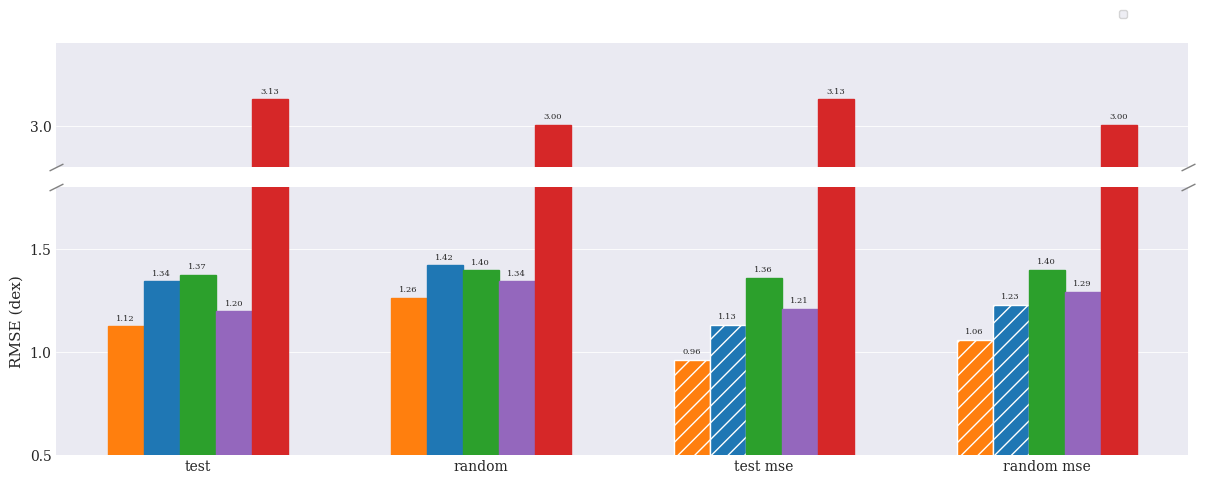

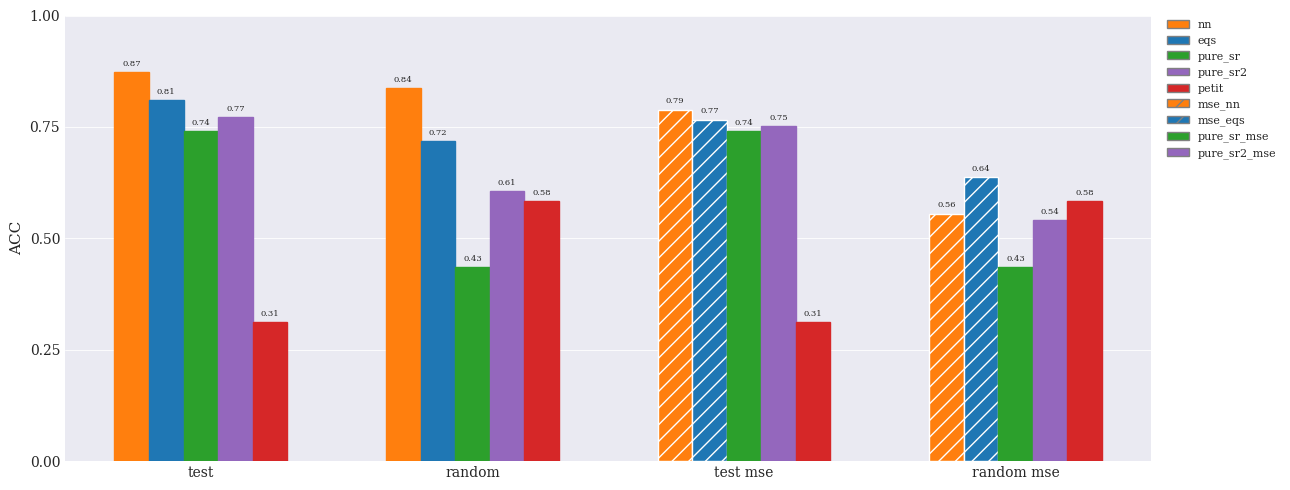

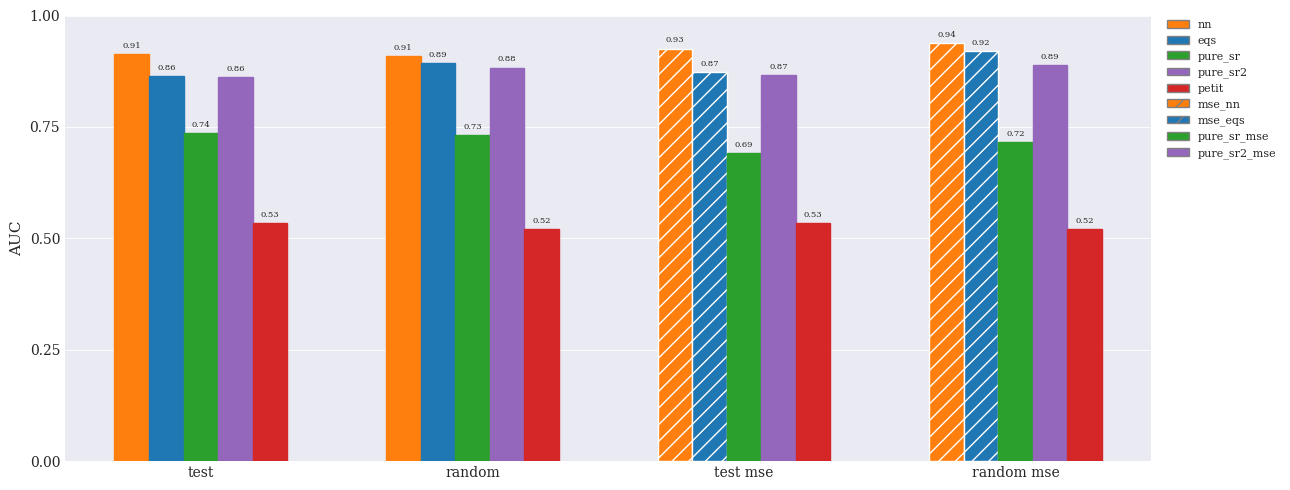

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from brokenaxes import brokenaxes
from matplotlib.ticker import MultipleLocator

cmap = plt.get_cmap('tab10')
# Match interpret.py: nn=orange(1), eqs=blue(0), pure_sr=green(2), petit=red(3); pure_sr2=purple(4)
color_map = {
    'nn':           cmap(1),
    'eqs':          cmap(0),
    'pure_sr':      cmap(2),
    'pure_sr2':     cmap(4),
    'petit':        cmap(3),
    'mse_nn':       cmap(1),
    'mse_eqs':      cmap(0),
    'pure_sr_mse':  cmap(2),
    'pure_sr2_mse': cmap(4),
}
hatch_map = {m: ('//' if m.startswith('mse_') else '') for m in color_map}

all_results_d = {
    'nn': nn, 'eqs': eqs, 'pure_sr': pure_sr, 'pure_sr2': pure_sr2,
    'petit': petit, 'mse_nn': mse_nn, 'mse_eqs': mse_eqs,
    'pure_sr_mse': pure_sr_mse, 'pure_sr2_mse': pure_sr2_mse,
}

groups = {
    'test':       ('test',   ['nn', 'eqs', 'pure_sr', 'pure_sr2', 'petit']),
    'random':     ('random', ['nn', 'eqs', 'pure_sr', 'pure_sr2', 'petit']),
    'test mse':   ('test',   ['mse_nn', 'mse_eqs', 'pure_sr_mse', 'pure_sr2_mse', 'petit']),
    'random mse': ('random', ['mse_nn', 'mse_eqs', 'pure_sr_mse', 'pure_sr2_mse', 'petit']),
}

bw = 0.14
group_gap = 1.1
x_centers = np.arange(len(groups)) * group_gap
group_names = list(groups.keys())
all_methods_ordered = ['nn', 'eqs', 'pure_sr', 'pure_sr2', 'petit',
                       'mse_nn', 'mse_eqs', 'pure_sr_mse', 'pure_sr2_mse']

def make_legend_handles():
    return [mpatches.Patch(facecolor=color_map[m], hatch=hatch_map[m],
                           edgecolor='gray', label=m)
            for m in all_methods_ordered]

def _draw_bars(bar_fn, annotate_fn, metric):
    """Draw bars and annotations for all groups. bar_fn(x, val, method) and annotate_fn(x, val)."""
    for g_idx, (group_name, (split, methods)) in enumerate(groups.items()):
        n = len(methods)
        center = x_centers[g_idx]
        offsets = (np.arange(n) - (n - 1) / 2) * bw
        for m_idx, method in enumerate(methods):
            val = all_results_d[method][split][metric]
            x_pos = center + offsets[m_idx]
            bar_fn(x_pos, val, method)
            annotate_fn(x_pos, val)

def make_rmse_plot():
    plt.style.use('seaborn-darkgrid')
    plt.rcParams['font.family'] = 'serif'

    fig = plt.figure(figsize=(13, 5))
    ylims = ((0.5, 1.8), (2.8, 3.4))
    bax = brokenaxes(ylims=ylims, hspace=0.1, despine=False,
                     subplot_spec=fig.add_gridspec(1, 1)[0])
    upper_ax, lower_ax = bax.axs[0], bax.axs[-1]

    def bar_fn(x, val, method):
        bax.bar(x, val, width=bw, color=color_map[method],
                hatch=hatch_map[method],
                edgecolor='white' if hatch_map[method] else color_map[method])

    def annotate_fn(x, val):
        ax = upper_ax if val > 1.8 else lower_ax
        ax.annotate(f'{val:.2f}', xy=(x, val), xytext=(0, 3),
                    textcoords='offset points', ha='center', va='bottom', fontsize=6)

    _draw_bars(bar_fn, annotate_fn, 'rmse')

    for ax in bax.axs:
        ax.grid(True, axis='y', linewidth=0.6)
        ax.grid(False, axis='x')

    upper_ax.tick_params(axis='y', labelleft=True)
    upper_ax.tick_params(axis='x', labelbottom=False)
    lower_ax.set_ylabel('RMSE (dex)', fontsize=11)
    lower_ax.set_xticks(x_centers)
    lower_ax.set_xticklabels(group_names, fontsize=10)
    lower_ax.yaxis.set_major_locator(MultipleLocator(0.5))
    upper_ax.yaxis.set_major_locator(MultipleLocator(0.5))

    # Slanted break lines
    d = 0.5
    kw = dict(marker=[(-1, -d), (1, d)], markersize=10,
              linestyle='none', color='grey', mec='grey', mew=1, clip_on=False)
    upper_ax.plot([0, 1], [0, 0], transform=upper_ax.transAxes, **kw)
    lower_ax.plot([0, 1], [1, 1], transform=lower_ax.transAxes, **kw)

    fig.subplots_adjust(right=0.84)
    bax.legend(handles=make_legend_handles(), loc='upper left',
               bbox_to_anchor=(0.86, 0.97), bbox_transform=fig.transFigure,
               frameon=True, fontsize=8)
    plt.tight_layout()
    plt.show()

def make_metric_plot(metric, ymax):
    plt.style.use('seaborn-darkgrid')
    plt.rcParams['font.family'] = 'serif'

    fig, ax = plt.subplots(figsize=(13, 5))

    def bar_fn(x, val, method):
        ax.bar(x, val, width=bw, color=color_map[method],
               hatch=hatch_map[method],
               edgecolor='white' if hatch_map[method] else color_map[method])

    def annotate_fn(x, val):
        if val <= ymax:
            ax.annotate(f'{val:.2f}', xy=(x, val), xytext=(0, 3),
                        textcoords='offset points', ha='center', va='bottom', fontsize=6)

    _draw_bars(bar_fn, annotate_fn, metric)

    ax.grid(True, axis='y', linewidth=0.6)
    ax.grid(False, axis='x')
    ax.set_xticks(x_centers)
    ax.set_xticklabels(group_names, fontsize=10)
    ax.set_ylabel(metric.upper(), fontsize=11)
    ax.set_ylim(top=ymax)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.legend(handles=make_legend_handles(), bbox_to_anchor=(1.01, 1), loc='upper left',
              borderaxespad=0, framealpha=0.9, fontsize=8)
    plt.tight_layout()
    plt.show()

make_rmse_plot()
make_metric_plot('acc', ymax=1.0)
make_metric_plot('auc', ymax=1.0)
